# **Práctica 1: Análisis exploratorio de dataset**
### Introducción a la Ciencia de Datos 
*Alumno: Norman O. Guzmán Chaboya*

La presente práctica tiene como objetivo realizar un análisis exploratorio sobre un conjunto de datos, detallando los siguientes atributos de este:
* Contexto y Procedencia.
* Estructura (y su verificación).
* Análisis de calidad de los datos.
* Sobre una selcción de atributos particulares:
    * Análisis univariado.
    * Análisis bivariado.
    * Análisis/vista multivariado(a).
* Hallazgos.
* Preguntas por contestar acerca del conjunto de datos.
* Problemas por superar en materia de datos.

Primeramente, importamos las bibliotecas necesarias para este proyecto, particularmente `pandas` nos hará posible explorar los contenidos del dataset seleccionado, y manipular los datos de tal manera que puedan darnos información organizada y presta para ser visualizada a través de `matplotlib` o `seaborn`

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.dates as mp_dates
import matplotlib.ticker as mticker
plt.style.use('bmh')
import seaborn as sns

Con el fin de visualizar simultáneamente dos o más tablas (como se verá más adelante en este notebook), se reuitlizó la función `display()` definida en el notebook [Combining Datasets: Concat and Append](https://github.com/husseinlopez/PythonDataScienceHandbook/blob/master/notebooks_v1/03.06-Concat-And-Append.ipynb) de la serie del libro *Python Data Science Handbook* de Jake VanderPlas, la cual resulta muy útil para discutir sobre el contenido de varios *dataframes*:

In [2]:
class display(object):
    # Función para observar simultáneamente múltiples objetos HTML
    template = """<div style="float: left; padding: 10px;">
    <p style='font-family:"Courier New", Courier, monospace'>{0}</p>{1}
    </div>"""
    def __init__(self, *args):
        self.args = args
        
    def _repr_html_(self):
        return '\n'.join(self.template.format(a, eval(a)._repr_html_())
                         for a in self.args)
    
    def __repr__(self):
        return '\n\n'.join(a + '\n' + repr(eval(a))
                           for a in self.args)

---

## Conjunto de Datos

#### Contexto y Procedencia
El *dataset* seleccionado se titula [Accidentes de Tránsito Terrestre en Zonas Urbanas y Suburbanas (ATUS)](https://www.inegi.org.mx/programas/accidentes/#datos_abiertos) y fue publicado por el INEGI en julio de 2026. Este contiene una antología de datos de accidentes de tránsito registrados por los gobiernos municipales en cada entidad del país. Cabe destacar que la información de los accidentes recabados aquí solo corresponde aquellos ocurridos en zonas no federales de México, e incluye registros pertinentes a los años comprendidos entre 1997 y 2025.



Para descargarlo, se puede hacer a través del siguiente link: \
https://www.inegi.org.mx/contenidos/programas/accidentes/datosabiertos/conjunto_de_datos_atus_anual_csv.zip

Por cuestiones de almanecenamiento y efectos prácticos de esta actividad, solamente se tomaron los datos correspondientes al año 2025. Como se podrá apreciar al analizar a detalle la tabla correspondiente, cada año contiene entre de 200 mil y 400 mil registros para cada año contemplado por el INEGI, reforzando la decisión de concentrarse únicamente en la información recabada durante el último año.

#### Licencia
Los datos compartidos por el INEGI están adscritos a la [Norma Técnica para el Acceso y Publicación de Datos Abiertos de la Información Estadística y Geográfica de Interés Nacional](https://www.snieg.mx/Documentos/Normatividad/Vigente/FT_Tecnica/FT_DA_IEG_IN.pdf), la cual estipula que los conjuntos de datos eleborados por esta institución están puestos a disposición del público en general como "Datos Abiertos", lo que implica un fácil acceso, uso, consulta, re-utilización y redistribución para cualquier fin.

Para cargar la tabla, utilizamos la función de `pandas` apropiada:

In [3]:
data_df = pd.read_csv('./data/atus_anual_2025.csv')

Y se muestra de la siguiente manera:

In [4]:
data_df

,COBERTURA,CVEGEO,CVE_ENT,CVE_MUN,ANIO,MES,ID_HORA,ID_MINUTO,ID_DIA,DIASEMANA,...,PEATMUERTO,PEATHERIDO,CICLMUERTO,CICLHERIDO,OTROMUERTO,OTROHERIDO,NEMUERTO,NEHERIDO,CLASACC,ESTATUS
0,Municipal,1001,1,1,2025,1,3,30,1,Miércoles,...,0,0,0,0,0,0,0,0,Sólo daños,Cifras Definitivas
1,Municipal,1001,1,1,2025,1,8,15,1,Miércoles,...,0,0,0,0,0,0,0,0,Sólo daños,Cifras Definitivas
2,Municipal,1001,1,1,2025,1,8,35,1,Miércoles,...,0,0,0,0,0,0,0,0,Sólo daños,Cifras Definitivas
3,Municipal,1001,1,1,2025,1,9,35,1,Miércoles,...,0,0,0,0,0,0,0,0,Sólo daños,Cifras Definitivas
4,Municipal,1001,1,1,2025,1,13,5,1,Miércoles,...,0,0,0,0,0,0,0,0,Sólo daños,Cifras Definitivas
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
380386,Municipal,32056,32,56,2025,12,22,43,26,Viernes,...,0,0,0,0,0,0,0,0,Sólo daños,Cifras Definitivas
380387,Municipal,32056,32,56,2025,12,3,42,27,Sábado,...,0,0,0,0,0,0,0,0,Sólo daños,Cifras Definitivas
380388,Municipal,32056,32,56,2025,12,22,0,27,Sábado,...,0,0,0,0,0,0,0,0,Sólo daños,Cifras Definitivas
380389,Municipal,32056,32,56,2025,12,1,45,28,Domingo,...,0,0,0,0,0,0,0,0,Sólo daños,Cifras Definitivas


A grandes rasgos, se sabe que la tabla contine un total de 380,391 registros (denotado por el número de filas), para los cuáles se han reportado un total de 46 atributos. Podemos utilizar la función/atributo del *dataframe* para ver rápidamente el listado de columnas y leer cuáles son todos los atributos que incluye la tabla:

In [5]:
print(data_df.columns)

Index(['COBERTURA', 'CVEGEO', 'CVE_ENT', 'CVE_MUN', 'ANIO', 'MES', 'ID_HORA',
       'ID_MINUTO', 'ID_DIA', 'DIASEMANA', 'URBANA', 'SUBURBANA', 'TIPACCID',
       'AUTOMOVIL', 'CAMPASAJ', 'MICROBUS', 'PASCAMION', 'OMNIBUS', 'TRANVIA',
       'CAMIONETA', 'CAMION', 'TRACTOR', 'FERROCARRI', 'MOTOCICLET',
       'BICICLETA', 'OTROVEHIC', 'CAUSAACCI', 'CAPAROD', 'SEXO', 'ALIENTO',
       'CINTURON', 'ID_EDAD', 'CONDMUERTO', 'CONDHERIDO', 'PASAMUERTO',
       'PASAHERIDO', 'PEATMUERTO', 'PEATHERIDO', 'CICLMUERTO', 'CICLHERIDO',
       'OTROMUERTO', 'OTROHERIDO', 'NEMUERTO', 'NEHERIDO', 'CLASACC',
       'ESTATUS'],
      dtype='str')


Y también podemos comprobar el tipo de dato para cada atributo, verificando que se cumple aquello declarado en el diccionario de datos:

In [6]:
print(data_df.dtypes)

COBERTURA       str
CVEGEO        int64
CVE_ENT       int64
CVE_MUN       int64
ANIO          int64
MES           int64
ID_HORA       int64
ID_MINUTO     int64
ID_DIA        int64
DIASEMANA       str
URBANA          str
SUBURBANA       str
TIPACCID        str
AUTOMOVIL     int64
CAMPASAJ      int64
MICROBUS      int64
PASCAMION     int64
OMNIBUS       int64
TRANVIA       int64
CAMIONETA     int64
CAMION        int64
TRACTOR       int64
FERROCARRI    int64
MOTOCICLET    int64
BICICLETA     int64
OTROVEHIC     int64
CAUSAACCI       str
CAPAROD         str
SEXO            str
ALIENTO         str
CINTURON        str
ID_EDAD       int64
CONDMUERTO    int64
CONDHERIDO    int64
PASAMUERTO    int64
PASAHERIDO    int64
PEATMUERTO    int64
PEATHERIDO    int64
CICLMUERTO    int64
CICLHERIDO    int64
OTROMUERTO    int64
OTROHERIDO    int64
NEMUERTO      int64
NEHERIDO      int64
CLASACC         str
ESTATUS         str
dtype: object


---

#### Estructura, Atributos y su calidad
A continuación se enlistan los atributos contenidos en la tabla, y agrupados de acuerdo a la dimensión a laz que pertenece con respecto al accidente. Esta descripción es un resumen de lo descrito por el Diccionario de Datos ([diccionario_de_datos_atus_anual_1997_2025.csv](./diccionario_de_datos_atus_anual_1997_2025.csv)) adjunto al conjunto de datos ATUS:

##### Identificación geográfica y temporal


- `COBERTURA`: Área geográfica a la que están referidos los indicadores (varchar, 200)
- `CVEGEO`: Clave geoestadística (char, 2), rango 01001 a 32058
- `ID_ENTIDAD`: Clave de la entidad federativa (char, 2), 01-32
- `ID_MUNICIPIO`: Clave del municipio (char, 3), 001-999
- `ANIO`: Año en que ocurrió el accidente (int), 1997-2025
- `MES`: Mes de referencia (varchar, 2), 01-12
- `ID_DIA`: Día del mes (varchar, 2), 01-31 (32 = no especificado)
- `DIASEMANA`: Día de la semana (varchar, 20), Lunes-Domingo, Certificado cero, No especificado
- `ID_HORA`: Hora del accidente (int), 0-23 (99 = no especificada)
- `ID_MINUTO`: Minuto del accidente (int), 0-59 (99 = no especificado)

##### Ubicación


- `URBANA`: Tipo de accidente en zona urbana (varchar, 50)
- `SUBURBANA`: Tipo de accidente en zona suburbana (varchar, 50)
- `CAPAROD`: Superficie de rodamiento (varchar, 50)

Podemos ver la cardinalidad de estos atributos tal y como fueron reportados en el archivo `.csv` agrupando por su respectiva columna:

In [7]:
# Utilizamos la función previamente discutida, la cual nos permite ver simultaneamente
# los 3 dataframes seleccionados
df_urbana = pd.DataFrame({'URBANA': data_df.loc[:, 'URBANA'].unique(),
                          'total': data_df.loc[:, 'URBANA'].value_counts().values}) # utilizando .unique(), se enlistan los casos únicos de la columna
df_suburbana = pd.DataFrame({'SUBURBANA': data_df.loc[:, 'SUBURBANA'].unique(), 
                            'total': data_df.loc[:, 'SUBURBANA'].value_counts().values}) # Zona suburbana
df_caparod = pd.DataFrame({'CAPAROD': data_df.loc[:, 'CAPAROD'].unique(),
                            'total': data_df.loc[:, 'CAPAROD'].value_counts().values}) # Superficie de rodamiento

display('df_urbana', 'df_suburbana', 'df_caparod') # Finalmente utilizamos display()

,URBANA,total
0,Accidente en no intersección,257149
1,Accidente en intersección,96014
2,Sin accidente en esta zona,27228
,SUBURBANA,total
0,Sin accidente en esta zona,353163
1,Accidente en carretera estatal,18295
2,Accidentes en otro camino,6204
3,Accidente en camino rural,2729
,CAPAROD,total
0,Pavimentada,374672


##### Características del accidente

- `TIPACCID`: Tipo de accidente (varchar, 100)
- `CAUSAACCI`: Causa presunta (varchar, 50)
- `CLASACC`: Clasificación de gravedad (varchar, 50)
- `ESTATUS`: Estatus de las cifras (varchar, 20)

In [8]:
df_tipaccid = pd.DataFrame({'TIPACCID': data_df.loc[:, 'TIPACCID'].unique(),
                           'total': data_df.loc[:, 'TIPACCID'].value_counts().values}) # Tipo de Accidente
df_causaacci = pd.DataFrame({'CAUSAACCI': data_df.loc[:, 'CAUSAACCI'].unique(),
                            'total': data_df.loc[:, 'CAUSAACCI'].value_counts().values}) # Causa del Accidente
df_clasacc = pd.DataFrame({'CLASACC': data_df.loc[:, 'CLASACC'].unique(),
                          'total': data_df.loc[:, 'CLASACC'].value_counts().values}) # Clasificación del Accidente
df_estatus  = pd.DataFrame({'ESTATUS': data_df.loc[:, 'ESTATUS'].unique(),
                           'total': data_df.loc[:, 'ESTATUS'].value_counts().values}) # Clasificación del Accidente

display('df_tipaccid', 'df_causaacci', 'df_clasacc', 'df_estatus')

,TIPACCID,total
0,Colisión con vehículo automotor,222241
1,Colisión con objeto fijo,68505
2,Colisión con motocicleta,43336
3,Colisión con peatón (atropellamiento),15412
4,Volcadura,10612
5,Colisión con ciclista,10000
6,Salida del camino,3999
7,Colisión con ferrocarril,2505
8,Otro,2142
9,Caída de pasajero,936


##### Vehículos involucrados (conteo por tipo, int, 0-9)

- `AUTOMOVIL`: Automóvil (hasta 7 asientos)
- `CAMPASAJ`: Camioneta de pasajeros (8-15 asientos)
- `MICROBUS`: Microbús (16-20 asientos)
- `PASCAMION`: Camión urbano de pasajeros (21-29 asientos)
- `OMNIBUS`: Ómnibus (30+ asientos)
- `TRANVIA`: Tren eléctrico o trolebús
- `CAMIONETA`: Camioneta de carga
- `CAMION`: Camión de carga
- `TRACTOR`: Tractor con o sin remolque
- `FERROCARRI`: Ferrocarril
- `MOTOCICLET`: Motocicleta
- `BICICLETA`: Bicicleta
- `OTROVEHIC`: Otro (ambulancias, grúas, tractores agrícolas, etc.)

 ##### Datos del conductor responsable

- `SEXO`: Género (varchar, 20), Se fugó, Hombre, Mujer, Certificado cero
- `ALIENTO`: Sobriedad (varchar, 20), Sí, No, Se ignora, Certificado cero
- `CINTURON`: Uso de cinturón de seguridad (varchar, 20), Sí, No, Se ignora, Certificado cero
- `ID_EDAD`: Edad (varchar, 2), 12-98 (0 = se fugó, 99 = se ignora)

In [9]:
df_sexo = pd.DataFrame({'SEXO': data_df.loc[:, 'SEXO'].unique(),
                       'total': data_df.loc[:, 'SEXO'].value_counts().values})
df_aliento = pd.DataFrame({'ALIENTO': data_df.loc[:, 'ALIENTO'].unique(),
                          'total': data_df.loc[:, 'ALIENTO'].value_counts().values})
df_cinturon = pd.DataFrame({'CINTURON': data_df.loc[:, 'CINTURON'].unique(),
                           'total': data_df.loc[:, 'CINTURON'].value_counts().values})
display('df_sexo', 'df_aliento', 'df_cinturon')

,SEXO,total
0,Hombre,283789
1,Mujer,61683
2,Se fugó,34919
,ALIENTO,total
0,Se ignora,229476
1,Sí,134698
2,No,16217
,CINTURON,total
0,Se ignora,294580
1,No,44147


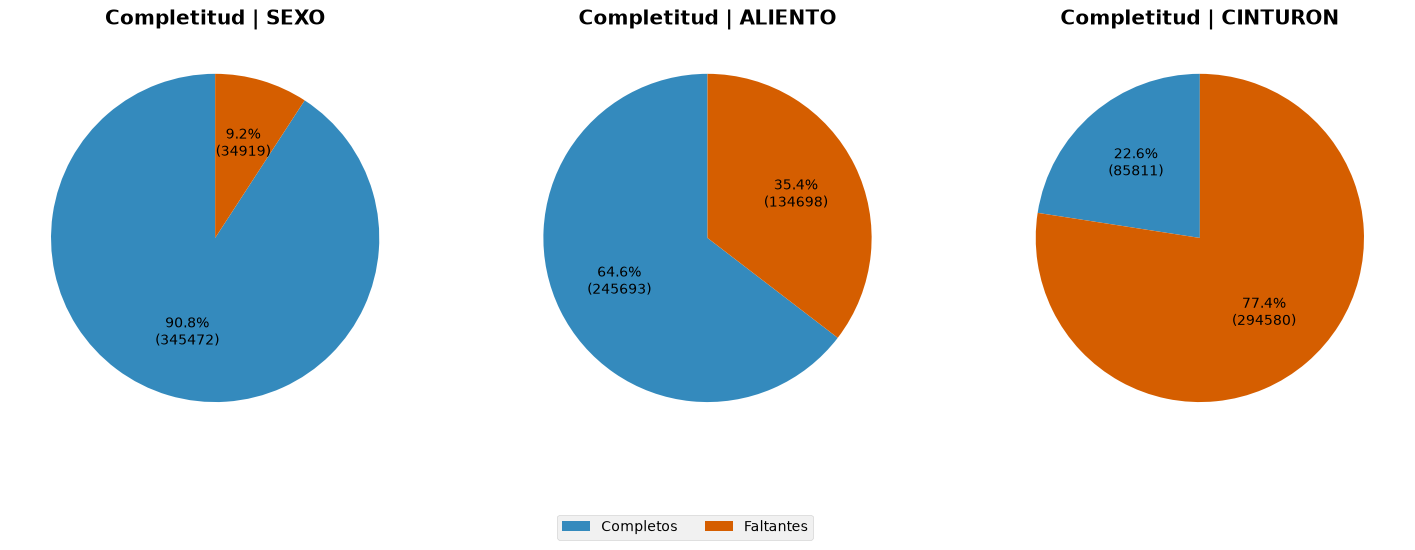

In [10]:
key = ['SEXO', 'ALIENTO', 'CINTURON']
null_key = ['Se fugó', 'Se ignora', 'Se ignora']
with plt.style.context('bmh'):
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    for i in range(3):
        faltantes = len(data_df[data_df[key[i]] == null_key[i]])
        completos = len(data_df[data_df[key[i]] != null_key[i]])
        total = completos + faltantes

        wedges, texts, autotexts = axes[i].pie(
            [completos, faltantes],
            autopct=lambda pct, total=total: f'{pct:.1f}%\n({int(round(pct/100*total))})',
            colors=['#348ABD', '#D55E00'],
            startangle=90
        )
        axes[i].set_title(f'Completitud | {key[i]}', fontweight='bold')

    fig.legend(
        wedges, ['Completos', 'Faltantes'],
        loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.02)
    )

        
    plt.show()

**Lectura:** Por un lado, el atributo `SEXO` tiene una tasa de incompletitud considerable pero lo suficientemente baja para ser manejable en una fase de procesamiento posterior, dónde los datos faltantes se pueden reemplazar utilizando alguna técnica de imputación clásica, o se podría considerar la eliminación de los registros faltantes. Sin embargo, lo mismo no se puede de decir de `ALIENTO` y `CINTURON`: los faltantes del primer atributo representan una tercera parte del total, por lo que se requeriría utilizar técnicas de imputación más avanzadas como KNN o por medio de Machine Learning, o eliminar la columna/atributo completamente; `ALIENTO` simplemente tiene una amplia mayoría de registros faltantes, por lo que difícilmente habría una forma de imputar los datos de forma efectiva y que respetara su distribución original.

##### Víctimas (muertos y heridos por categoría, int, 0-99)

- `CONDMUERTO` / `CONDHERIDO`: Conductores muertos / heridos
- `PASAMUERTO` / `PASAHERIDO`: Pasajeros muertos / heridos
- `PEATMUERTO` / `PEATHERIDO`: Peatones muertos / heridos
- `CICLMUERTO` / `CICLHERIDO`: Ciclistas muertos / heridos
- `OTROMUERTO` / `OTROHERIDO`: Otros involucrados muertos / heridos (personas en inmuebles, mantenimiento, construcción, etc.)
- `NEMUERTO` / `NEHERIDO`: Víctimas muertas / heridas no clasificadas por la fuente
---

## Limpieza 

Para reducir las dimensiones de la tabla, he optado por fusionar los datos númericos/temporales en una sola variable en formato de *timestamp*, dejando únicamente la variable ordinal `DIASEMANA`. Primeramente, verifico la completitud de los datos temporales que de acuerdo al diccionario, pudieran estar reportados como faltantes de acuerdo a su respectivo código validado:

In [11]:
# Primeramente, verifico la completitud de los datos temporales que de acuerdo al diccionario 
#print(np.sort(data_df['ID_HORA'].unique()))
for col in [[32, 'ID_DIA'], [99, 'ID_MINUTO'], [99,'ID_HORA']]:
    # Agrupamos y enlistamos vals. únicos
    print (f"¿Se encontró un valor no reportado para '{col[1]}' (código {col[0]})?: {col[0] in data_df[col[1]].unique()}") 

¿Se encontró un valor no reportado para 'ID_DIA' (código 32)?: False
¿Se encontró un valor no reportado para 'ID_MINUTO' (código 99)?: False
¿Se encontró un valor no reportado para 'ID_HORA' (código 99)?: False


Puesto que no se encontraron faltantes para ninguno de los atributos necesarios, no se requerirá hacer ninguna otra operación como pudiera ser imputación o elimnación de registros incompletos.
\
\
Lo siguiente es fusionar los datos númericos/temporales en un *timestamp*:


In [12]:
# fusionamos las series en otra de tipo datetime
date_series = pd.to_datetime({
    'day': data_df['ID_DIA'],       # Dia
    'month': data_df['MES'],        # Mes
    'year': data_df['ANIO'],        # Año
    'hour': data_df['ID_HORA'],     # Hora
    'minute': data_df['ID_MINUTO'], # Minuto
})

loc = data_df.columns.get_loc('ANIO') 
data_df.insert(loc, "FECHA", date_series) # Insertamos justo en la posición que tiene 'ANIO'

#Eliminamos las columnas/atributos que ya no necesitaremos más
data_df = data_df.drop(columns=['ID_DIA', 'MES', 'ANIO', 'ID_HORA', 'ID_MINUTO'])

data_df.head(1)

,COBERTURA,CVEGEO,CVE_ENT,CVE_MUN,FECHA,DIASEMANA,URBANA,SUBURBANA,TIPACCID,AUTOMOVIL,...,PEATMUERTO,PEATHERIDO,CICLMUERTO,CICLHERIDO,OTROMUERTO,OTROHERIDO,NEMUERTO,NEHERIDO,CLASACC,ESTATUS
0,Municipal,1001,1,1,2025-01-01 03:30:00,Miércoles,Accidente en no intersección,Sin accidente en esta zona,Colisión con vehículo automotor,2,...,0,0,0,0,0,0,0,0,Sólo daños,Cifras Definitivas


También verificamos si existen duplicados dentro de los registros. Para hacer esto, se decidió que los atributos clave para comparar entre sí para comprobar duplicidad serían la edad del culpable (`ID_EDAD`), la fecha del altercado (`FECHA`), el ID del municipio en el que ocurrió dicho accidente(`CVE_MUN`), y el tipo de este (`TIPACCID`).

In [13]:
key_cols = ['FECHA', 'CVE_MUN', 'ID_EDAD', 'TIPACCID']
sum_faltantes = data_df.duplicated(subset=key_cols, keep=False).sum()

print(f'Total de duplicados tomando como claves FECHA, CVE_MUN, ID_EDAD y TIPACCID: {sum_faltantes}')

Total de duplicados tomando como claves FECHA, CVE_MUN, ID_EDAD y TIPACCID: 2949


In [14]:
duplicados = data_df[data_df.duplicated(subset=key_cols, keep=False)]
duplicados[key_cols].sort_values("FECHA").head(6)

,FECHA,CVE_MUN,ID_EDAD,TIPACCID
52534,2025-01-01 00:00:00,19,99,Colisión con objeto fijo
52536,2025-01-01 00:00:00,19,99,Colisión con objeto fijo
52535,2025-01-01 00:00:00,19,99,Colisión con objeto fijo
21984,2025-01-01 10:30:00,2,99,Colisión con motocicleta
21985,2025-01-01 10:30:00,2,99,Colisión con motocicleta
345699,2025-01-01 15:20:00,32,99,Colisión con vehículo automotor


Al parecer, se obtuvieron un total de 4133 registros duplicados. Como se puede apreciar en el ejemplo, dos accidentes en el mismo municipio, a la misma hora, con el mismo tipo de accidente y el mismo culpable (acotado por su edad), difícilmente podrían ocurrir simultáneamente; no sería imposible, pero sí muy poco probables de que ocurrieran bajo las mismas circunstancias. \
Lo siguiente es remover estos registros duplicados de nuestro conjunto de datos:

In [15]:
data_df = data_df.drop_duplicates(subset=key_cols, keep='first')
print(f"Duplicados removidos: {sum_faltantes}\nNuevo total de registros tras limpieza: {len(data_df)}")

Duplicados removidos: 2949
Nuevo total de registros tras limpieza: 378848


---

## Análisis Univariado

Empezamos con la variables númericas, primeramente por los atributos que muestran los conteos de los diferentes tipos de vehículos involucrados:

In [16]:
# Columnas de tipos de vehículos 
cols_vehiculo = ['AUTOMOVIL', 'CAMPASAJ', 'MICROBUS', 'PASCAMION', 'OMNIBUS', 
               'TRANVIA','CAMIONETA', 'CAMION', 'TRACTOR', 'FERROCARRI', 
               'MOTOCICLET', 'BICICLETA', 'OTROVEHIC']
data_df[cols_vehiculo].describe().round(2).T # Describimos estadísticamente

,count,mean,std,min,25%,50%,75%,max
AUTOMOVIL,378848.0,1.15,0.76,0.0,1.0,1.0,2.0,8.0
CAMPASAJ,378848.0,0.22,0.48,0.0,0.0,0.0,0.0,6.0
MICROBUS,378848.0,0.00,0.07,0.0,0.0,0.0,0.0,3.0
PASCAMION,378848.0,0.04,0.20,0.0,0.0,0.0,0.0,3.0
OMNIBUS,378848.0,0.00,0.06,0.0,0.0,0.0,0.0,2.0
TRANVIA,378848.0,0.00,0.02,0.0,0.0,0.0,0.0,1.0
CAMIONETA,378848.0,0.13,0.36,0.0,0.0,0.0,0.0,4.0
CAMION,378848.0,0.04,0.20,0.0,0.0,0.0,0.0,4.0
TRACTOR,378848.0,0.03,0.17,0.0,0.0,0.0,0.0,3.0
FERROCARRI,378848.0,0.00,0.03,0.0,0.0,0.0,0.0,2.0


**Lectura:** Primeramente, tenemos un promedio de 1.15 (desv. est. de 0.76) para el conteo de automóviles, comparado con el resto de vehículos reportados, es aquel que más aparece como involucrado en los reportes de accidentes. El primer cuártil, Q1=1 indica que están involucrados en alrededor del 75% o más de total de accidentes. El máximo de 8 implica la existencia de choques múltiples con este número de inmvolucrados. \
Los siguientes dos vehículos más reportados son las motocicletas y las camionetas de pasajeros (de 8 a 15 plazas), con promedios de 0.25 y 0.22, respectivamente, lo que indica que su presencia es considerable, aunque su ausencia en los primeros 3 cuártiles indica que su presencia es rara. \
El resto de vehículos son todavía más dificiles de encontrar, aunque las camionetas particulares y camiones de carga tienen un alto máximo, indicando que suelen encontrarse en choques múltiples.



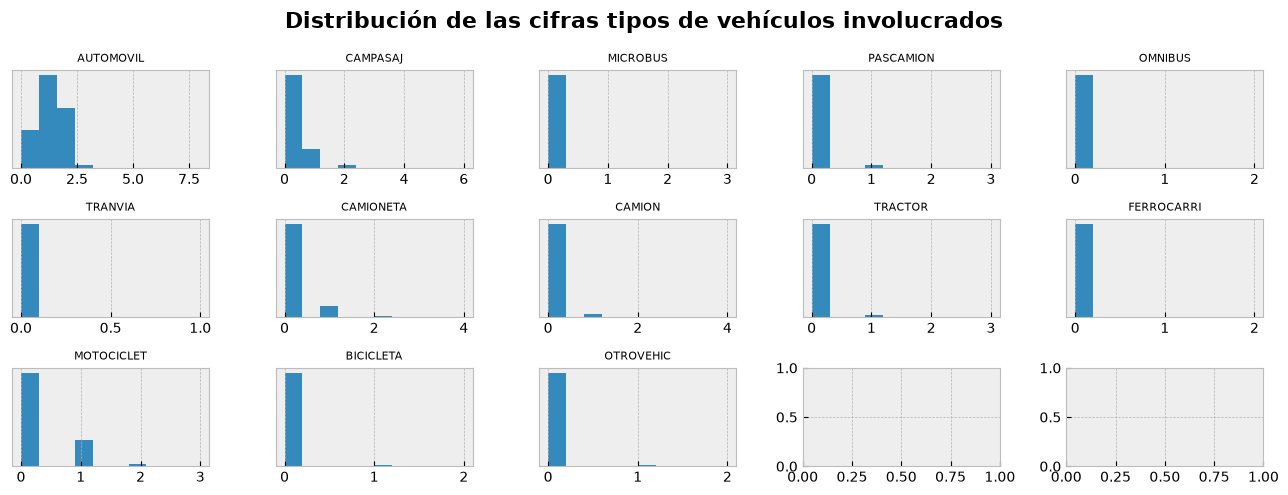

In [17]:
fig, axes = plt.subplots(3, 5, figsize=(13, 5))

# Graficamos el histograma de distribución para cada tipo de vehículo involucrado
with plt.style.context('bmh'):
    for ax, col in zip(axes.ravel(), cols_vehiculo):
        ax.hist(data_df[col], bins=10)
        ax.set_title(col, fontsize=8)
        ax.set_yticks([])
    
    fig.suptitle("Distribución de las cifras tipos de vehículos involucrados",
                 fontsize=16, fontweight="bold")
    plt.tight_layout()
    plt.show()

**Lectura**: Los histogramas de distribución confirman lo descrito por los estimadores previamente reportados, la presencia de vehículos diferentes de automóviles particulares, motocicletas o camionetas de pasajeros es muy rara y tiende a ser cero.

In [18]:
# Columnas de cifras de heridos y muertos 
cols_cifras = ['CONDMUERTO', 'CONDHERIDO', 'PASAMUERTO', 'PASAHERIDO', 
               'PEATMUERTO', 'PEATHERIDO', 'CICLMUERTO', 'CICLHERIDO', 
               'OTROMUERTO', 'OTROHERIDO', 'NEMUERTO', 'NEHERIDO']
data_df[cols_cifras].describe().round(2).T # Describimos

,count,mean,std,min,25%,50%,75%,max
CONDMUERTO,378848.0,0.01,0.08,0.0,0.0,0.0,0.0,3.0
CONDHERIDO,378848.0,0.13,0.35,0.0,0.0,0.0,0.0,15.0
PASAMUERTO,378848.0,0.00,0.07,0.0,0.0,0.0,0.0,15.0
PASAHERIDO,378848.0,0.07,0.41,0.0,0.0,0.0,0.0,40.0
PEATMUERTO,378848.0,0.00,0.05,0.0,0.0,0.0,0.0,3.0
PEATHERIDO,378848.0,0.03,0.18,0.0,0.0,0.0,0.0,11.0
CICLMUERTO,378848.0,0.00,0.02,0.0,0.0,0.0,0.0,1.0
CICLHERIDO,378848.0,0.01,0.08,0.0,0.0,0.0,0.0,3.0
OTROMUERTO,378848.0,0.00,0.01,0.0,0.0,0.0,0.0,2.0
OTROHERIDO,378848.0,0.00,0.02,0.0,0.0,0.0,0.0,2.0


**Lectura:** Como se aprecia a simple vista con los promedios, la existencia de personas afectadas (muertas o heridas) en un accidente suelen ser ocurrencias raras, el caso más frecuente es el de un conductor hérido. Cabe destacar que existen casos, según el máximo de conductores heridos, en los que se tienen hasta de 13 de ellos simultáneamente, posiblemente a consecuencia de un choque múltiple. Los casos con mayores máximos son aquellos pertinentes a pasajeros heridos y pasajeros muertos.

Con el fin de hacer un análisis posterior sobre el total de cifras de heridos y de muertos, se agruparon las cifras particulares en un par de columnas nuevas que corresponden a cada caso:

In [19]:
muerto_cols = ['CONDMUERTO', 'PASAMUERTO', 'PEATMUERTO', 'CICLMUERTO', 'OTROMUERTO', 'NEMUERTO']
herido_cols = ['CONDHERIDO', 'PASAHERIDO', 'PEATHERIDO', 'CICLHERIDO', 'OTROHERIDO', 'NEHERIDO']

# Creamos un par de columnas que agrupan el total de muertos y de heridos
data_df['TOTAL_MUERTOS'] = data_df[muerto_cols].sum(axis=1)
data_df['TOTAL_HERIDOS'] = data_df[herido_cols].sum(axis=1)

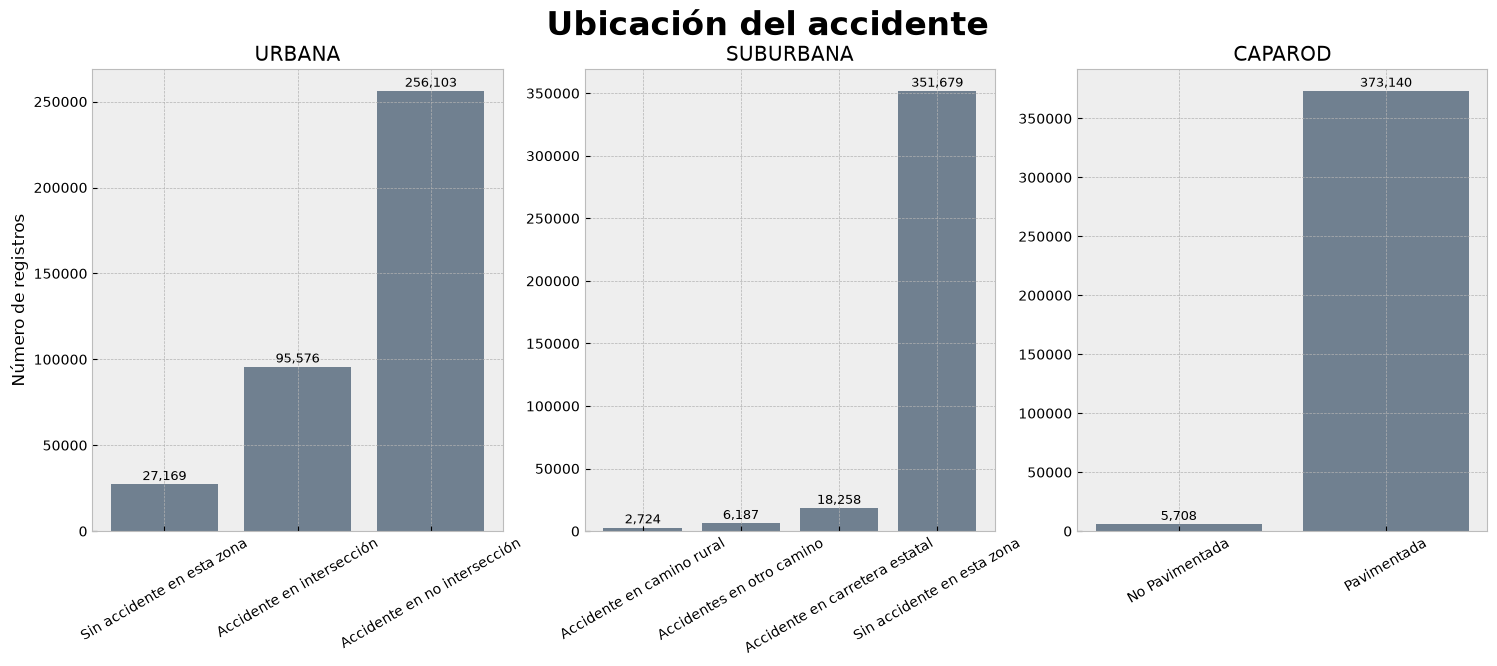

In [20]:
# Ubicación del accidente
key = ['URBANA', 'SUBURBANA', 'CAPAROD']

with plt.style.context('bmh'):
    fig, ax = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle('Ubicación del accidente', fontweight='bold', fontsize=24)
    ax[0].set_ylabel('Número de registros')
    for i in range(3):
    
        table = pd.DataFrame({key[i]: data_df.loc[:, key[i]].unique(),
                               'total': data_df.loc[:, key[i]].value_counts().values})
    
        table = table.sort_values('total', ascending=True)  
        
        ax[i].bar(table[key[i]], table['total'], color='slategrey')
        ax[i].set_title(key[i])
    
    
        for j, v in enumerate(table['total']):
            ax[i].text(j, v + max(table['total'])*0.01, f'{v:,}', ha='center', fontsize=9)
        ax[i].tick_params(axis='x', labelrotation=30)
        
    plt.show()

**Lectura:** los accidentes en zonas urbanas y suburbanas son mútuamente excluyentes; la mayoría de accidentes se concentran en las zonas urbanas, normalmente en los segmentos de calle que no son intersección (sobre calles, avenidas, entre otros); en zonas suburbanas, los accidentes se concentran en carreteras estatales y la minoría corresponde a accidentes en caminos rurales. Por último, la inmensa mayoría de accidentes registrados ocurrieron sobre vialidades pavimentadas. En general, existe un sesgo extremo que favorece a los accidentes urbanos, y dentro de esta categoría de ubicación, la mayoría (~70%) tiende a concentrarse sobre vialidades.  

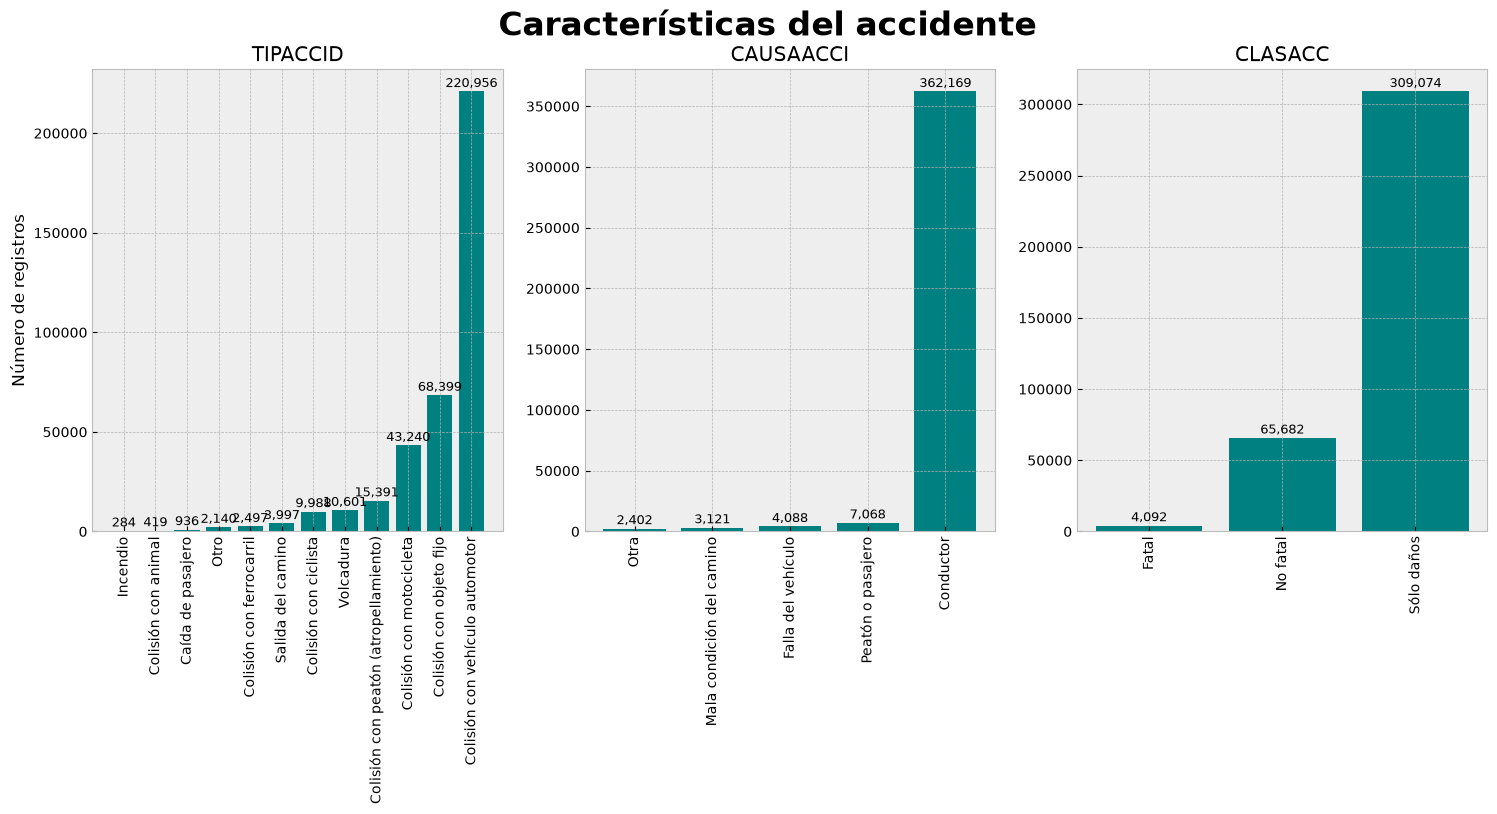

In [21]:
key = ['TIPACCID', 'CAUSAACCI', 'CLASACC'] # Características del accidente

with plt.style.context('bmh'):
    fig, ax = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle('Características del accidente', fontweight='bold', fontsize=24)
    ax[0].set_ylabel('Número de registros')
    for i in range(3):
    
        table = pd.DataFrame({key[i]: data_df.loc[:, key[i]].unique(),
                               'total': data_df.loc[:, key[i]].value_counts().values})
    
        table = table.sort_values('total', ascending=True)  
        
        ax[i].bar(table[key[i]], table['total'], color='teal')
        ax[i].set_title(key[i])
    
    
        for j, v in enumerate(table['total']):
            ax[i].text(j, v + max(table['total'])*0.01, f'{v:,}', ha='center', fontsize=9)
        ax[i].tick_params(axis='x', labelrotation=90)
        
    plt.show()

**Lectura:** primeramente, observando el tipo de accidentes (`TIPACCID`), la inmensa mayoría corresponde a accidentes que involucran la colisión de dos o más vehículos, seguido de lejos por las colisiones contra objetos fijos. Asimismo, al ver los tipos de causas (`CAUSAACCI`), una única clase domina sobre las demás y apunta a los conductores de vehículos como responsables en más del 90% de accidentes. La clasificación de accidentes (`CLASACC`) indica que la gran mayoría de los registros declaran que solo hubo daños materiales; la ocurrencia de accidentes fatales es extremadamente rara (~1% de todos los casos); la distribución de las categorías en este atributo en particular explica la tendencia de las cifras de vehículos involucrados y de afectados, previamente visto en la tabla de estimadores. 

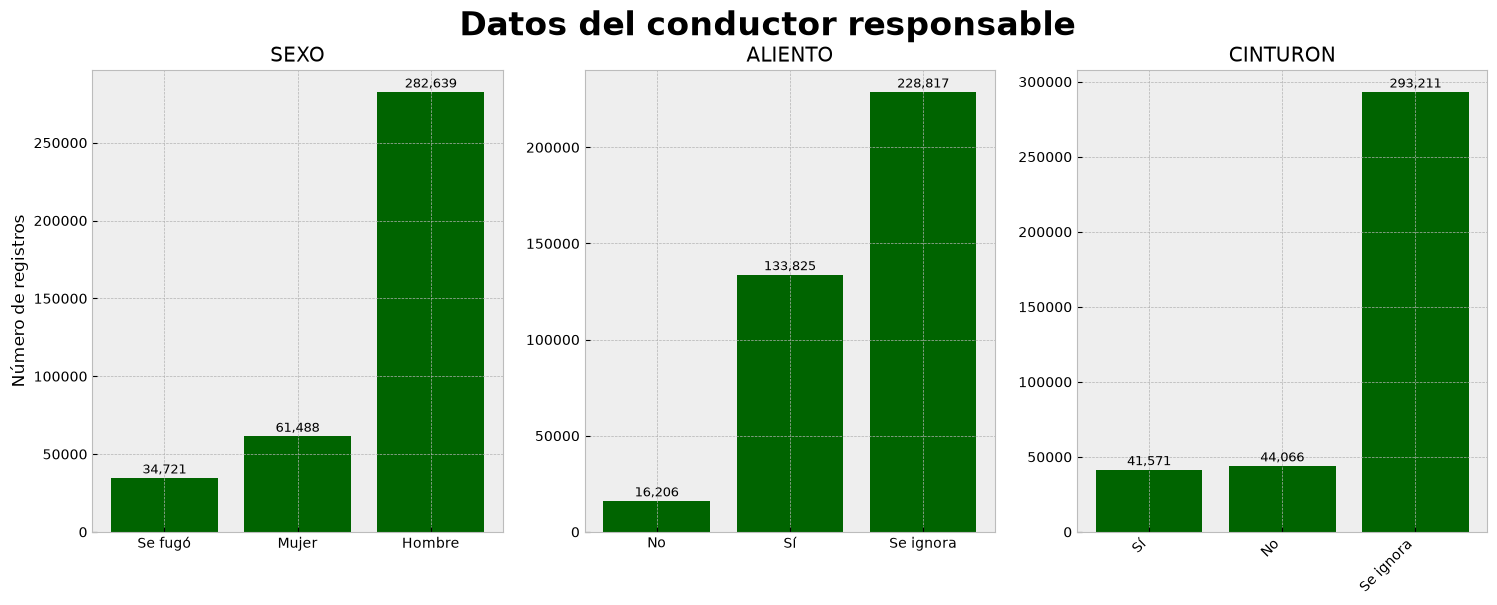

In [22]:
key = ['SEXO', 'ALIENTO', 'CINTURON']

with plt.style.context('bmh'):
    fig, ax = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle('Datos del conductor responsable', fontweight='bold', fontsize=24)
    ax[0].set_ylabel('Número de registros')
    for i in range(3):
    
        table = pd.DataFrame({key[i]: data_df.loc[:, key[i]].unique(),
                               'total': data_df.loc[:, key[i]].value_counts().values})
    
        table = table.sort_values('total', ascending=True)  
        
        ax[i].bar(table[key[i]], table['total'], color='darkgreen')
        ax[i].set_title(key[i])
    
        plt.xticks(rotation=45, ha='right')
    
        for j, v in enumerate(table['total']):
            ax[i].text(j, v + max(table['total'])*0.01, f'{v:,}', ha='center', fontsize=9)
        
    plt.show()

**Lectura:** Los histogramas de distribución muestran lo que previamente se había discutido respecto a datos implícitamente faltantes, particularmente el atributo binario `CINTURON` posee un número grande de faltantes, aunque curiosamente, los registros presentes se encuentran relativamente balancedos entre las dos condiciones. Lo mismo no se puede decir sobre el sexo del culpable: en esta categoría, la mayoría está dada a los hombres que son responsables en más del 70% de los resgistros. Los casos de fuga representan ~10% del total. Por otro lado, faltan alrededor de dos terceras partes de los datos correspondientes al aliento alcohólico del culpable (`ALIENTO`), y de aquellos registros reportados, la gran mayoría de registros afirman que sí se presentó esta condición. 

---

Para visualizar el conteo de accidentes por entidad, primero mapeamos los nombres de cada estado con la clave correspondiente en la tabla original, utilizando el [mapa designado](./catalogos/tc_entidad.csv):

In [23]:
map_tc_entidad = pd.read_csv('./catalogos/tc_entidad.csv')
map_tc_entidad = map_tc_entidad[['CVE_ENT','NOM_ENTIDAD']]
map_tc_entidad.head(2)

,CVE_ENT,NOM_ENTIDAD
0,1,Aguascalientes
1,2,Baja California


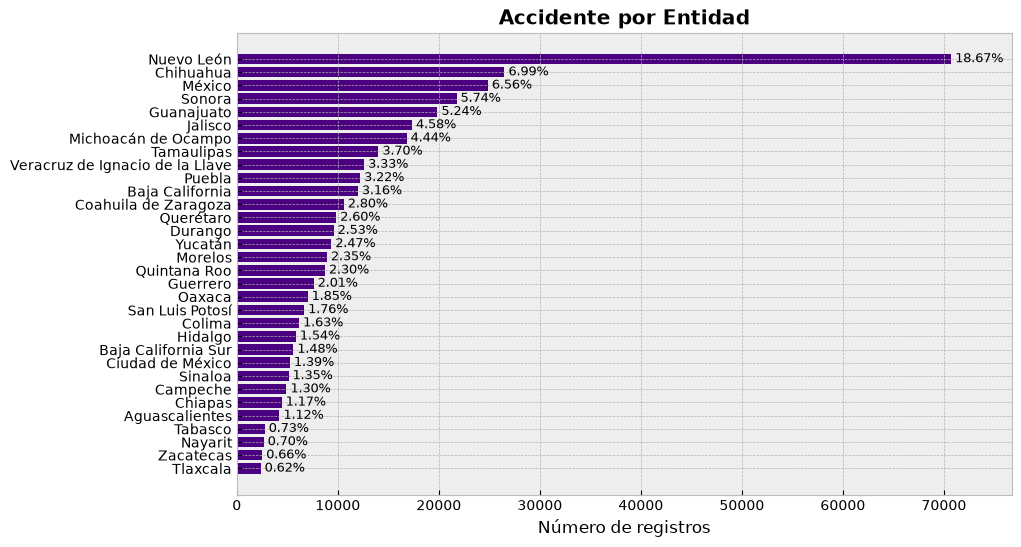

In [24]:
conteo_entidad = pd.DataFrame({ "conteo": data_df.groupby("CVE_ENT").size() })

mapping = map_tc_entidad.set_index('CVE_ENT')['NOM_ENTIDAD']
conteo_entidad['estado'] = conteo_entidad.index.map(mapping)

with plt.style.context('bmh'):
    fig, ax = plt.subplots(figsize=(10, 6))

    df_sorted = conteo_entidad.sort_values('conteo', ascending=True)

    ax.barh(df_sorted['estado'], df_sorted['conteo'], color='indigo')
    ax.set_xlabel('Número de registros')
    ax.set_title('Accidente por Entidad', fontweight='bold')

    total = np.sum(conteo_entidad['conteo'])
    
    for i, v in enumerate(df_sorted['conteo']):
        ax.text(v, i, f' {(v/total)*100:.2f}%', va='center', fontsize=9)

    ax.set_xlim(0, np.max(conteo_entidad['conteo']+6000))
    plt.show()

**Lectura:** El siguiente hisotgrama muestra el conteo del total de accidentes reportados por entidad. Nuevo León destaca extraordinariamente: representa casi el 20% del total de accidentes en el país, muy por arriba del Estado de México y Ciudad de México, ambos estados que incluyen el área metropolitana de la capital y ciudad más poblada del país. El segundo estado por conteo es Chihuahua, con ~7%, seguido muy de cerca del Estado de México. Tlaxcala se encuentra en el último lugar.  

---

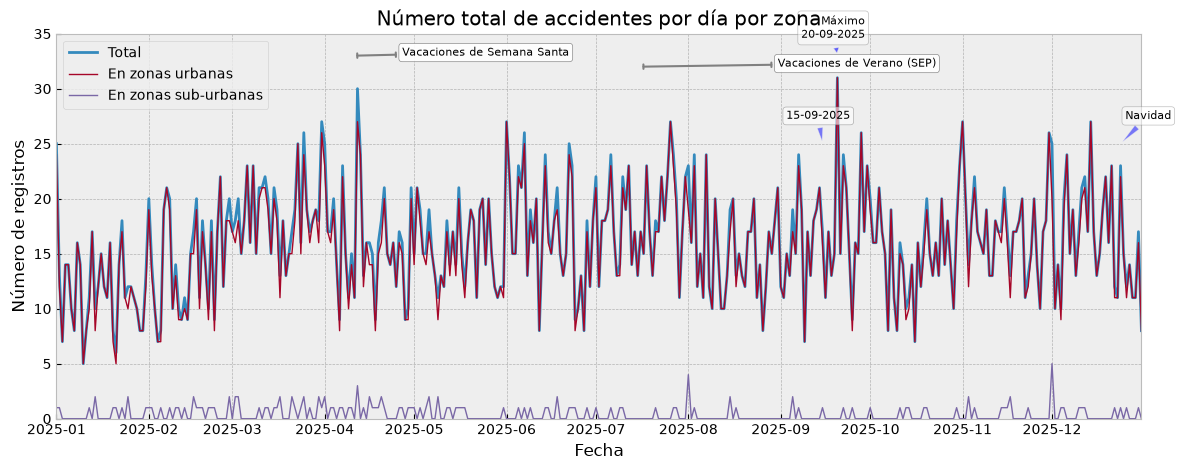

In [25]:
ar = 'Sin accidente en esta zona'
date_range = pd.date_range("2025-01-01", "2025-12-31", freq="D")

# Organizamos un rango de fechas sobre los registros reportados para mapear la serie de tiempo
d_series = data_df.groupby("FECHA").size()
d_series = d_series.reindex(date_range, fill_value=0)

# Agrupamos los accidentes por zona, descartando las categorías que excluyen mútuamente a ambos atributos
urbana_series = data_df[data_df["URBANA"] != ar].groupby("FECHA").size()
urbana_series = urbana_series.reindex(date_range, fill_value=0)
suburbana_series = data_df[data_df["SUBURBANA"] != ar].groupby("FECHA").size()
suburbana_series = suburbana_series.reindex(date_range, fill_value=0)

with plt.style.context('bmh'):
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(d_series.index, d_series.values, linewidth=2, label="Total")
    ax.plot(urbana_series.index, urbana_series.values, linewidth=1, label="En zonas urbanas")
    ax.plot(suburbana_series.index, suburbana_series.values, linewidth=1, label="En zonas sub-urbanas")
    ax.set_title("Número total de accidentes por día por zona")
    ax.set_xlabel("Fecha")
    ax.set_ylabel("Número de registros")

    # Anotar un indicador del periodo vacacional de verano de la sep
    ax.annotate(f"Vacaciones de Verano (SEP)", 
            xy=(pd.Timestamp('2025-07-16'),32), 
            xytext=(pd.Timestamp('2025-08-31'), 32),
            xycoords='data', textcoords='data',
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.9),
            arrowprops={'arrowstyle': '|-|,widthA=0.2,widthB=0.2', 
                        'color': 'grey',
                        'linewidth': 1.5},
            fontsize=8);

    # Otro indicador de periodo, ahora para Semana Santa
    ax.annotate(f"Vacaciones de Semana Santa", 
            xy=(pd.Timestamp('2025-04-11'), 33), 
            xytext=(pd.Timestamp('2025-04-27'), 33),
            xycoords='data', textcoords='data',
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.9),
            arrowprops={'arrowstyle': '|-|,widthA=0.2,widthB=0.2', 
                        'color': 'grey',
                        'linewidth': 1.5},
            fontsize=8)

    # Marcamos puntulmente la fecha de 25 de diciembre
    ax.annotate('Navidad', xy=(pd.Timestamp('2025-12-24'), 25),  xycoords='data',
             xytext=(20, 20), textcoords='offset points',
             size=8, ha='center', va="center",
             bbox=dict(boxstyle="round", alpha=0.5, fc="white", ec="gray"),
             arrowprops=dict(arrowstyle="wedge,tail_width=0.5", alpha=0.5));

    # Localizamos 
    ax.annotate('15-09-2025', xy=(pd.Timestamp('2025-09-15'), 25),  xycoords='data',
             xytext=(20, 20), textcoords='offset points',
             size=8, ha='right', va="center",
             bbox=dict(boxstyle="round", alpha=0.6, fc="white", ec="gray"),
             arrowprops=dict(arrowstyle="wedge,tail_width=0.5", alpha=0.5));
    
    max_acc = d_series.idxmax()
    ts_max_str = max_acc.strftime('%d-%m-%Y') 
    
    ax.annotate(f'Máximo\n{ts_max_str}', xy=(max_acc, 33),  xycoords='data',
             xytext=(20, 20), textcoords='offset points',
             size=8, ha='right', va="center",
             bbox=dict(boxstyle="round", alpha=0.5, fc="white", ec="gray"),
             arrowprops=dict(arrowstyle="wedge,tail_width=0.5", alpha=0.6));

    ax.set_ylim(0, 35)
    ax.set_xlim(pd.Timestamp('2025-01-01'), pd.Timestamp('2025-12-31'))
    
    ax.legend(frameon=True)
    
    plt.show()

**Lectura:** La siguiente gráfica muestra el número de accidentes por día en cada una de las zonas reportadas. Como ya se había observado en el histograma de distribución, la mayoría corresponde a accidentes ocurridos en zonas urbanas. También podemos apreciar picos en el número de reportes: particularmente, al inicio del periodo vacacional de Semana Santa se observa un incremento notorio, reportado en un solo día; también se puede notar un número constante de reportes diarios en zonas suburbanas durante este periodo. El máximo número de reportes diarios tuvo lugar el 20 de septiembre.

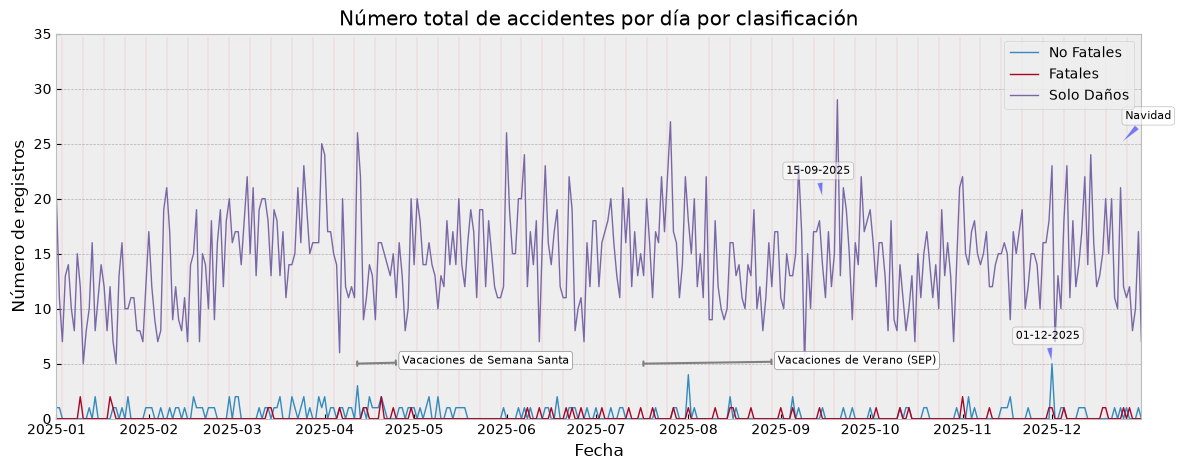

In [26]:
fatales_series = data_df[data_df["CLASACC"] == 'Fatal'].groupby("FECHA").size()
fatales_series = fatales_series.reindex(date_range, fill_value=0)
nofatales_series = data_df[data_df["CLASACC"] == 'No fatal'].groupby("FECHA").size()
nofatales_series = suburbana_series.reindex(date_range, fill_value=0)
danos_series = data_df[data_df["CLASACC"] == 'Sólo daños'].groupby("FECHA").size()
danos_series = danos_series.reindex(date_range, fill_value=0)


with plt.style.context('bmh'):
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(nofatales_series.index, nofatales_series.values, linewidth=1, label="No Fatales")
    ax.plot(fatales_series.index, fatales_series.values, linewidth=1, label="Fatales")
    ax.plot(danos_series.index, danos_series.values, linewidth=1, label="Solo Daños")
    ax.set_title("Número total de accidentes por día por clasificación")
    ax.set_xlabel("Fecha")
    ax.set_ylabel("Número de registros")
    
    ax.annotate(f"Vacaciones de Verano (SEP)", 
            xy=(pd.Timestamp('2025-07-16'),5), 
            xytext=(pd.Timestamp('2025-08-31'), 5),
            xycoords='data', textcoords='data',
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.9),
            arrowprops={'arrowstyle': '|-|,widthA=0.2,widthB=0.2', 
                        'color': 'grey',
                        'linewidth': 1.5},
            fontsize=8);

    ax.annotate(f"Vacaciones de Semana Santa", 
            xy=(pd.Timestamp('2025-04-11'), 5), 
            xytext=(pd.Timestamp('2025-04-27'), 5),
            xycoords='data', textcoords='data',
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.9),
            arrowprops={'arrowstyle': '|-|,widthA=0.2,widthB=0.2', 
                        'color': 'grey',
                        'linewidth': 1.5},
            fontsize=8)

    ax.annotate('Navidad', xy=(pd.Timestamp('2025-12-24'), 25),  xycoords='data',
             xytext=(20, 20), textcoords='offset points',
             size=8, ha='center', va="center",
             bbox=dict(boxstyle="round", alpha=0.5, fc="white", ec="gray"),
             arrowprops=dict(arrowstyle="wedge,tail_width=0.5", alpha=0.5));

    ax.annotate('15-09-2025', xy=(pd.Timestamp('2025-09-15'), 20),  xycoords='data',
             xytext=(20, 20), textcoords='offset points',
             size=8, ha='right', va="center",
             bbox=dict(boxstyle="round", alpha=0.5, fc="white", ec="gray"),
             arrowprops=dict(arrowstyle="wedge,tail_width=0.5", alpha=0.5));

    ax.annotate('01-12-2025', xy=(pd.Timestamp('2025-12-01'), 5),  xycoords='data',
             xytext=(20, 20), textcoords='offset points',
             size=8, ha='right', va="center",
             bbox=dict(boxstyle="round", alpha=0.5, fc="white", ec="gray"),
             arrowprops=dict(arrowstyle="wedge,tail_width=0.5", alpha=0.5));

    ax.xaxis.set_minor_locator(mp_dates.WeekdayLocator(byweekday=mp_dates.FR))
    ax.xaxis.set_minor_formatter(mticker.NullFormatter())
    ax.tick_params(axis='x', which='minor', color = (1, 0, 0, 0.7), length=275, width=0.1, )
    ax.grid(which='major', axis='x', visible=False)
    
    ax.set_ylim(0, 35)
    ax.set_xlim(pd.Timestamp('2025-01-01'), pd.Timestamp('2025-12-31'))
    
    ax.legend(frameon=True)
    
    plt.show()

**Lectura:** En esta serie de tiempo, se reporta el registro de accidentes por día de acuerdo a su letalidad. Se pueden notar los mismos picos durante los mismos periodos de tiempo que en la gráfica anterior de zonas, pero a diferencia de esos, la cuadrícula (en rojo) denota el día viernes de cada semana; siguiendo este enfoque, se puede notar que durante estos días incurren la mayoría de picos en accidentes letales y no letales. 

## Análisis Bivariado

Primeramente, convertimos el atributo categórico de la clasificación del accidente a una escala numérica:

In [27]:
data_df_gravedad = data_df.copy()

In [28]:
mapa_gravedad = pd.DataFrame({'CLASACC': ['Sólo daños','No fatal','Fatal'], 'clave': [1, 2, 3]})
mapping = mapa_gravedad.set_index('CLASACC')['clave']

data_df_gravedad = data_df.copy()
data_df_gravedad['CLASACC'] = data_df_gravedad['CLASACC'].map(mapping)

**Pregunta: ¿cómo se relaciona el aliento alcohólico con la letalidad de un accidente?**

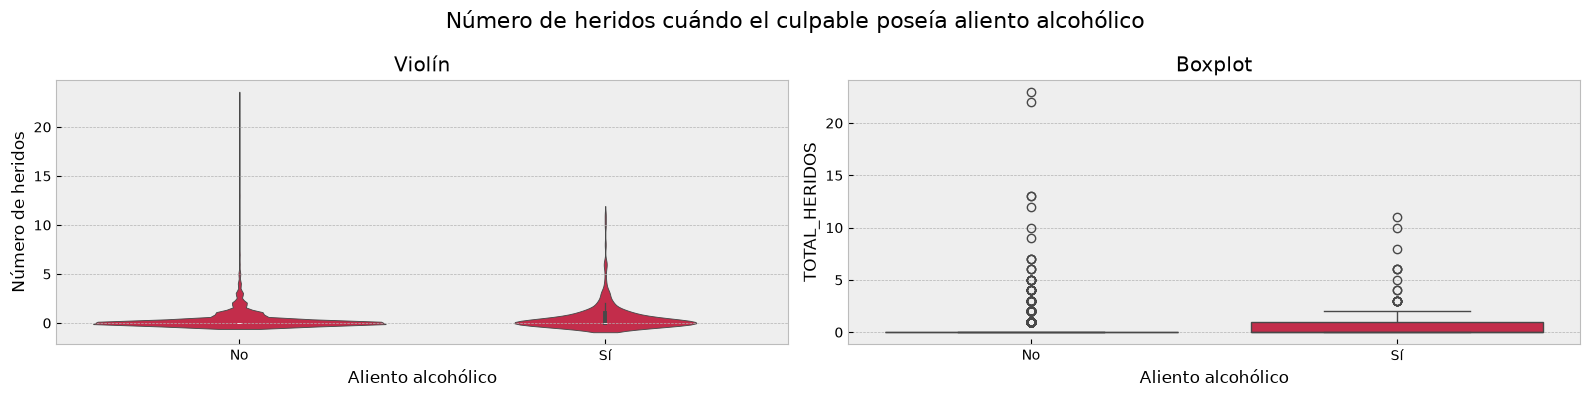

In [29]:
with plt.style.context('bmh'):
    fig, axes = plt.subplots(1, 2, figsize=(16, 4))
    fig.suptitle('Número de heridos cuándo el culpable poseía aliento alcohólico', size=16)
    table = data_df_gravedad[(data_df_gravedad["CLASACC"] == 3) & (data_df_gravedad["ALIENTO"] != 'Se ignora')]
    aliento = table["ALIENTO"].value_counts().index

    sns.violinplot(data=table, x="ALIENTO", y="TOTAL_HERIDOS",
                   order=aliento, color='crimson', ax=axes[0])
    axes[0].set_xlabel("Aliento alcohólico")
    axes[0].set_ylabel("Número de heridos")
    axes[0].set_title("Violín")

    sns.boxplot(data=table, x="ALIENTO", y="TOTAL_HERIDOS",
                order=aliento, color='crimson', ax=axes[1])
    axes[1].set_xlabel("Aliento alcohólico")
    axes[1].set_title("Boxplot")

    plt.tight_layout()
    plt.show()

**Lectura:** El par de gráficos muestra la distrubución del total de héridos dependiendo del aliento alcohólico del culpable. Ambas categorías  muestran distribuciones extremadamente sesgadas, con la gran mayoría de los accidentes concentrados de 0 a 1. Cuando no hay aliento alcohólico reportado, se registran datos atípicos que corresponden, en su mayoría a accidentes de 2 a 10 heridos, y con registros aún más extraordinarios en arriba de 20 heridos. Sin embargo, si observamos la distribución de los casos dónde sí se detectó, particularmente en el *boxplot* notamos que en los cuártiles centrales se extienden a 1 herido, mostrando que los conductores bajo estos efectos tienden a verse involucrados en accidentes que producen al menos un herido en una proporción mucho mayor a los casos contrarios. 

**Pregunta: ¿Cómo se relaciona la presencia de un automóvil particular involucrado con el total de muertes en un accidente?**

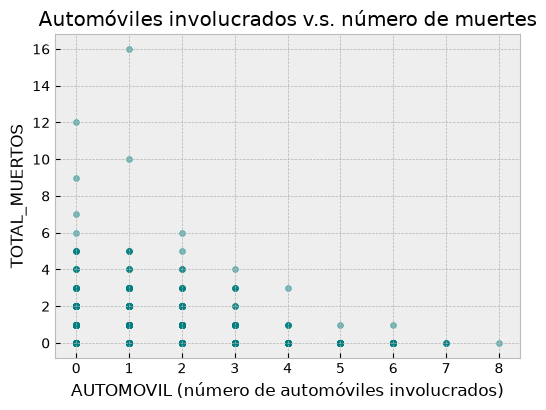

In [44]:
with plt.style.context('bmh'):
    fig, ax = plt.subplots(figsize=(6, 4.2))
    
    table = data_df_gravedad.copy()
    
    ax.scatter(table["AUTOMOVIL"], table["TOTAL_MUERTOS"],
               s=18, alpha=0.5, color='teal')
    
    ax.set_xlabel("AUTOMOVIL (número de automóviles involucrados)")
    ax.set_ylabel("TOTAL_MUERTOS")
    ax.set_title("Automóviles involucrados v.s. número de muertes")
    plt.show()

**Lectura:** Se observa una tendencia inversa: a medida que aumenta el número de automóviles involucrados, disminuye tanto la frecuencia como la magnitud de las muertes reportadas, con los accidentes de 6 a 8 automóviles concentrados casi exclusivamente en 0 muertes. Los registros más extraordinarios (e. g. 16 muertos) corresponden todos a eventos que involucran entre 0 y 1, lo que sugiere que los accidentes más letales del conjunto de datos no involucran choques múltiples de automóviles, sino otro tipo de vehículo con mayor capacidad de pasajeros.

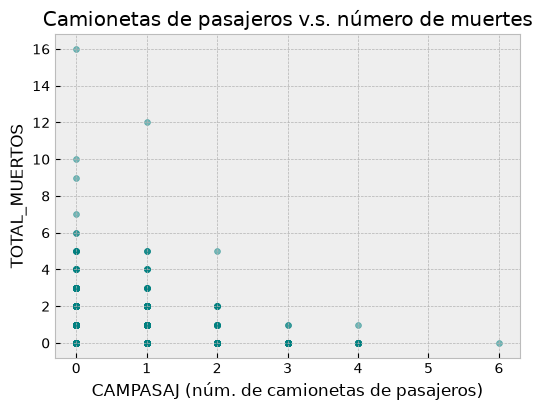

In [39]:
with plt.style.context('bmh'):
    fig, ax = plt.subplots(figsize=(6, 4.2))
    
    table = data_df_gravedad.copy()
    
    ax.scatter(table["CAMPASAJ"], table["TOTAL_MUERTOS"],
               s=18, alpha=0.5, color='teal')
    
    ax.set_xlabel("CAMPASAJ (núm. de camionetas de pasajeros)")
    ax.set_ylabel("TOTAL_MUERTOS")
    ax.set_title("Camionetas de pasajeros v.s. número de muertes")
    plt.show()

**Lectura:** Al igual que con los automóviles, se observa una tendencia inversa. A medida que aumenta el número de camionetas de pasajeros involucradas, disminuye tanto la frecuencia como la magnitud de las muertes reportadas, con los accidentes de 5 y 6 camionetas concentrados exclusivamente en 0 muertes. 

## Análisis Multivariado 

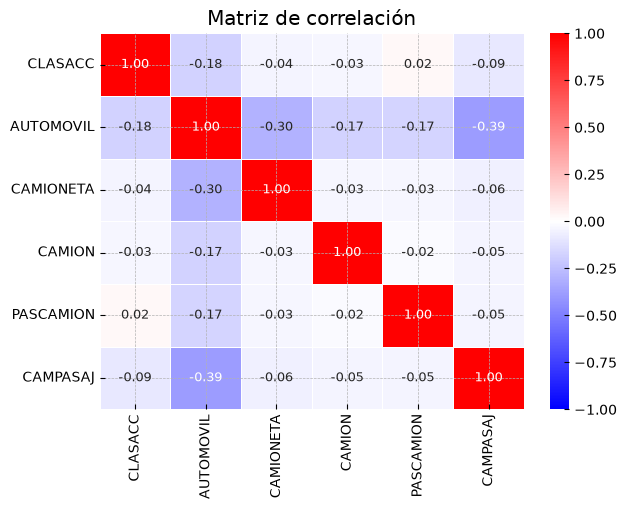

In [32]:
cols_vehiculo_selected = ['AUTOMOVIL', 'CAMIONETA', 'CAMION', 'PASCAMION', 'CAMPASAJ']

correlaciones = data_df_gravedad[
    ['CLASACC'] + cols_vehiculo_selected
].corr()

fig, ax = plt.subplots(figsize=(6.5, 5.2))

sns.heatmap(correlaciones, cmap="bwr", center=0, vmin=-1, vmax=1,
            annot=True, fmt=".2f", annot_kws={"size": 9},
            linewidths=0.6, linecolor="white", ax=ax)

ax.set_title("Matriz de correlación")
plt.tight_layout()
plt.show()

**Lectura:** la correlación más fuerte del conjunto se da entre `AUTOMOVIL` y `CAMPASAJ` (-0.39), seguida de `AUTOMOVIL` y `CAMIONETA` (-0.30), lo que indica que la presencia de automóviles en un accidente tiende a asociarse inversamente con la presencia de camionetas de pasajeros y camionetas en general. el atributo correspondiente a automóviles particulares destaca como la variable más influyente de la matriz, mostrando correlaciones moderadas negativas con casi todas las demás categorías. Con respecto a la clasificación de gravedad del accidente (`CLASSAC`), la mayoría de atributos se correlacionan muy débilmente y de manera inversa, lo que muestra que el conteo de vehículos involucrados no necesariamente determina si accidente es fatal o no. 

---

## Conclusiones

Los hallazgos fueron los siguientes:
- Existen muy poco registros de accidentes en los que se indique si el culpable portaba el cinturón de seguridad.
- Nuevo León por sí solo ha sido lugar para el 20% de los accidentes reportados en 2025. Esto se puede deber en mayor medida al hecho que Monterrey en comparación a otras áreas metropolitanas de tamaño y población similares, no posee un sistema de transporte público eficiente y de amplia covertura, y que además es otra urbe que da prioridad al automóvil particular en materia de movilidad, situación común en el norte del país y que también puede explicar que:
    - Chihuahua y Sonora ocupan el 2do y 4to lugar, respectivamente por total de accidentes registrados.
- El día con el máximo número de accidentes fue el 20 de septiembre
- El inicio del periodo vacacional de semana santa implicó otro pico muy cercano en el número de accidentes, notablemente aquellos que resultaron fatales, y durante este mismo periodo ocurrió el máximo número de accidentes fatales en un solo día 
- Existe un patrón de temporada con picos de accidentes fatales y no fatales (con al menos un hérido) en los días viernes del año.
- El aliento alcohólico propicia un aumento en la incurrencia de accidentes no fatales.

Asimismo, este análisis preliminar abre otra serie de preguntas:
- ¿Cómo se relaciona el tipo de accidente con la ubicación del accidente (zonas urbana/suburbana)?
- ¿Qué tipo de accidentes se reportan más en cada entidad? ¿Qué nos podrían decir las diferencias entre lo reportado en una entidad y en otra?
- ¿En qué hora del día suceden más accidentes?

Por último, en cuanto a lo que los datos concierne lo que queda pendiente por hacer es:
- Eliminar los registros con faltantes del atributo `SEXO`
- Buscar una manera efectiva de imputar aquellos en `ALIENTO`

#### Declaración de uso de Inteligencia Artificial Generativa
Para la siguiente práctica, se utlizó Claude para realizar ajustes en el formato de algunos de los gráficos presentados, particularmente aquellos que incluían series de tiempo. 